<a href="https://colab.research.google.com/github/Master-45-vic/CEG-ML-Competition/blob/main/Mater_of_Smart_Grid_Power_Load_in_India.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Grid / Power Load in India

## 1. Overview

India's power grid is one of the largest and most complex in the world. While thermal (coal) power provides the baseload, renewable sources like Hydroelectric and Nuclear power are critical for maintaining grid stability and reducing carbon emissions.

However, these sources have unique challenges:

Hydro Power is highly seasonal, depending heavily

*   Hydro Power is highly seasonal, depending heavily on monsoon rains and reservoir levels.
*   Nuclear Power is stable but requires precise scheduling for maintenance and fueling.



If grid operators can accurately forecast the generation capacity of these sources, they can better optimize the usage of coal and prevent power deficits (blackouts).

## 2. Goal

Goal is to build a Machine Learning **model that forecasts the Daily Power Generation** (in Million Units - MU) for Hydro and Nuclear power plants across India's five regional grids (Northern, Western, Southern, Eastern, North-Eastern).

## 3. Data Understanding

### 3.1 Load Data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/CEG ML Competitiom/CEG ML Competition/Smart Grid  Power Load in India/train.csv", index_col='id')
display(df.head())

,date,source,Region,Generation
id,,,,
1,2013-03-31,Hydro,ER,30.0
2,2013-03-31,Hydro,NER,7.0
3,2013-03-31,Hydro,NR,139.0
4,2013-03-31,Hydro,SR,72.0
5,2013-03-31,Hydro,WR,43.0


### 3.2 Shape of Data

In [ ]:
df.shape

(22995, 4)



*   No of Rows = 22995
*   No of Columns = 4




### Columns Description



*   id - Unique row identifier.
*   date - The date of the record.
*  source - The type of power plant:
  
         *  Hydro: Dependent on water levels/monsoon.
         *  Nuclear: Generally stable but subject to maintenance cycles.

*   Region - The power grid region:

         *   NR: Northern Region
         *   WR: Western Region
         *   SR: Southern Region
         *   ER: Eastern Region
         *   NER: North Eastern Region

*   Generation - (TARGET) The actual power generated in Million Units (MU).




### 3.3 Data Types of Each Columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22995 entries, 1 to 22995
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        22995 non-null  object 
 1   source      22995 non-null  object 
 2   Region      22995 non-null  object 
 3   Generation  22995 non-null  float64
dtypes: float64(1), object(3)
memory usage: 898.2+ KB


*   data,source and region are **object** data type
*   generation is **float** data type



### 3.4 Number of Unique Value in Each Columns

In [ ]:
def unique_count(df):
  for i in df.columns:
    count = df[i].nunique()
    print(i, ": ", count)
unique_count(df)

date :  3044
source :  2
Region :  5
Generation :  387


### 3.5 Number of NaN Values

In [ ]:
def NaN_count(df):
  for i in df.columns:
    count = df[i].isna().sum()
    print(i, ": ", count)
NaN_count(df)

date :  0
source :  0
Region :  0
Generation :  0


### 3.6 Duplicate Records

In [ ]:
print("Number of Duplicate Records : ",df.duplicated().sum())

Number of Duplicate Records :  90


## 4. Exploratory Data Analysis

In [ ]:
#Convert the date (Object) to date (datetime)
#Create Day,Month,Year,dayofweek,weekofyear,quarter and is_weekend

df['date'] = pd.to_datetime(df['date'])
df['Day'] = df['date'].dt.day
df['Month'] = df['date'].dt.month
df['Year'] = df['date'].dt.year
df['dayofweek'] = df['date'].dt.dayofweek
df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter
df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)
df = df.sort_values(by=['Region','source','date'])
display(df.head())

,date,source,Region,Generation,Day,Month,Year,dayofweek,weekofyear,quarter,is_weekend
id,,,,,,,,,,,
1,2013-03-31,Hydro,ER,30.0,31,3,2013,6,13,1,1
6,2013-04-01,Hydro,ER,32.0,1,4,2013,0,14,2,0
11,2013-04-02,Hydro,ER,29.0,2,4,2013,1,14,2,0
16,2013-04-03,Hydro,ER,38.0,3,4,2013,2,14,2,0
21,2013-04-04,Hydro,ER,38.0,4,4,2013,3,14,2,0


In [ ]:
df.head()

,date,source,Region,Generation,Day,Month,Year,dayofweek,weekofyear,quarter,is_weekend
id,,,,,,,,,,,
1,2013-03-31,Hydro,ER,30.0,31,3,2013,6,13,1,1
6,2013-04-01,Hydro,ER,32.0,1,4,2013,0,14,2,0
11,2013-04-02,Hydro,ER,29.0,2,4,2013,1,14,2,0
16,2013-04-03,Hydro,ER,38.0,3,4,2013,2,14,2,0
21,2013-04-04,Hydro,ER,38.0,4,4,2013,3,14,2,0


### 4.1 Univariate Analysis

4.1.1 Generation Statistics

In [ ]:
df['Generation'].describe()

,Generation
count,22995.000000
mean,60.211002
std,73.178085
min,0.000000
25%,18.000000
50%,34.000000
75%,75.000000
max,463.000000


4.1.2 Histogram : Distribution of Generation (Million Units)

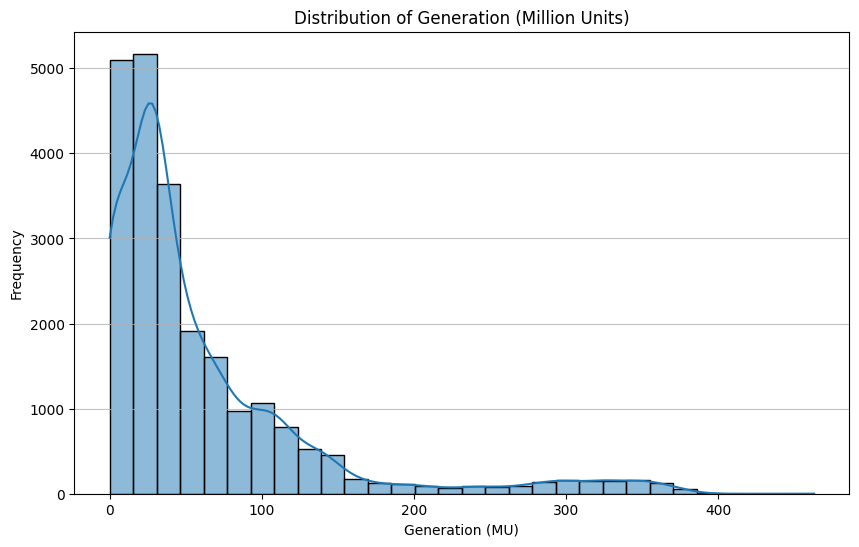

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Generation'], kde=True, bins=30)
plt.title('Distribution of Generation (Million Units)')
plt.xlabel('Generation (MU)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

Analysis :

1. Positively Skewed Distribution
2. Majority of Values Below 100 MU
3. Presence of High-Value Outliers

### 4.2 Bivariate Analysis

4.2.1 Line Plot : Avg generation over time

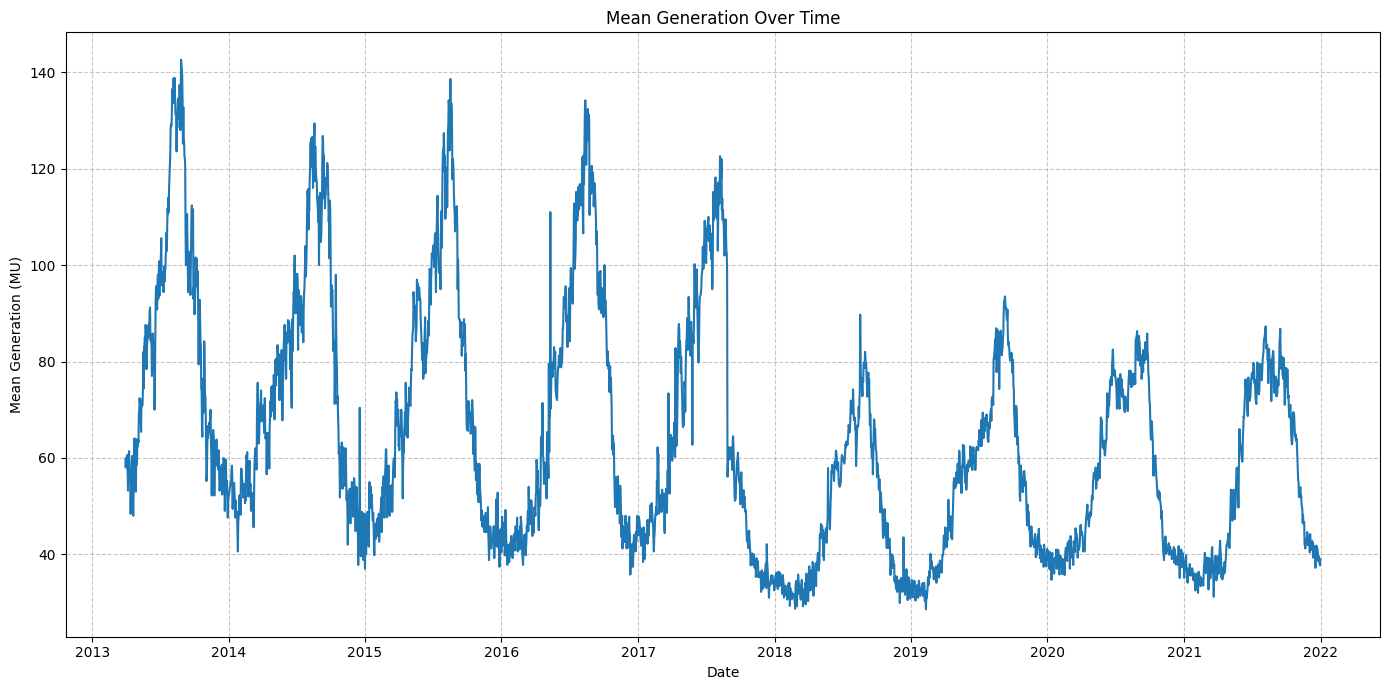

In [ ]:
mean_generation_by_date = df.groupby('date')['Generation'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=mean_generation_by_date, x='date', y='Generation')
plt.title('Mean Generation Over Time')
plt.xlabel('Date')
plt.ylabel('Mean Generation (MU)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Analysis :

1. Seasonal Pattern
2. Overall Decline in Peak Generation
3. Lower Minimums in Later Years



4.2.2 Bar Chart : Year-wise Average Generation

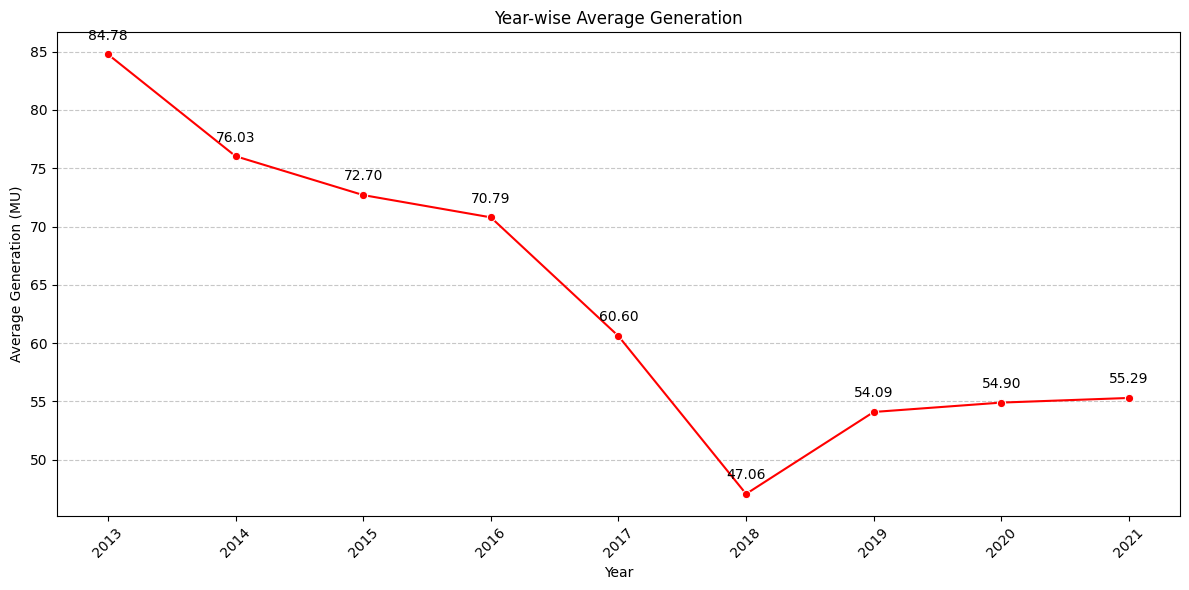

In [ ]:
avg_generation_per_year = df.groupby('Year')['Generation'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=avg_generation_per_year.index, y=avg_generation_per_year.values, marker='o', color='red')

for index, value in enumerate(avg_generation_per_year.values):
    plt.text(avg_generation_per_year.index[index], value + 1, f'{value:.2f}', color='black', ha='center', va='bottom', fontsize=10)

plt.title('Year-wise Average Generation')
plt.xlabel('Year')
plt.ylabel('Average Generation (MU)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Analysis

1. Strong Declining Trend (2013–2018)

2. 2018 is the Lowest Point (Major Dip Year)

3. Recovery & Stabilization After 2018

4.2.3 Grouped Bar Chart : Year-wise Average Generation by Source

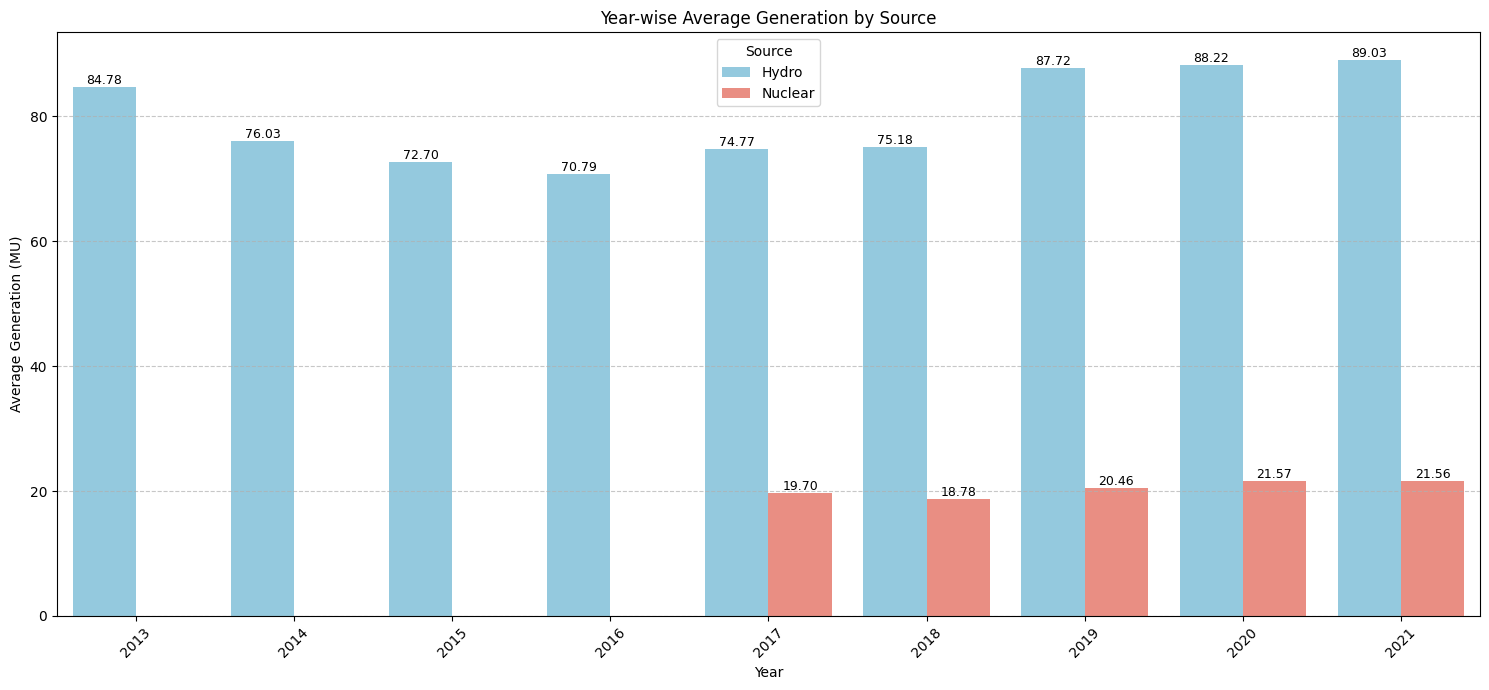

In [ ]:
avg_generation_yearly_source = df.groupby(['Year', 'source'])['Generation'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.barplot(data=avg_generation_yearly_source, x='Year', y='Generation', hue='source', palette={'Hydro': 'skyblue', 'Nuclear': 'salmon'})

# Add average values on top of the bars
for container in plt.gca().containers:
    for bar in container:
        height = bar.get_height()
        plt.gca().text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.title('Year-wise Average Generation by Source')
plt.xlabel('Year')
plt.ylabel('Average Generation (MU)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(title='Source')
plt.tight_layout()
plt.show()

Analysis :

1. Hydro Shows a Dip Then Strong Recovery

2. Nuclear is Stable with Slight Growth

3. Hydro Contributes Significantly More Than Nuclear

4.2.4 Grouped Bar Chart : Year-wise Average Generation by Region

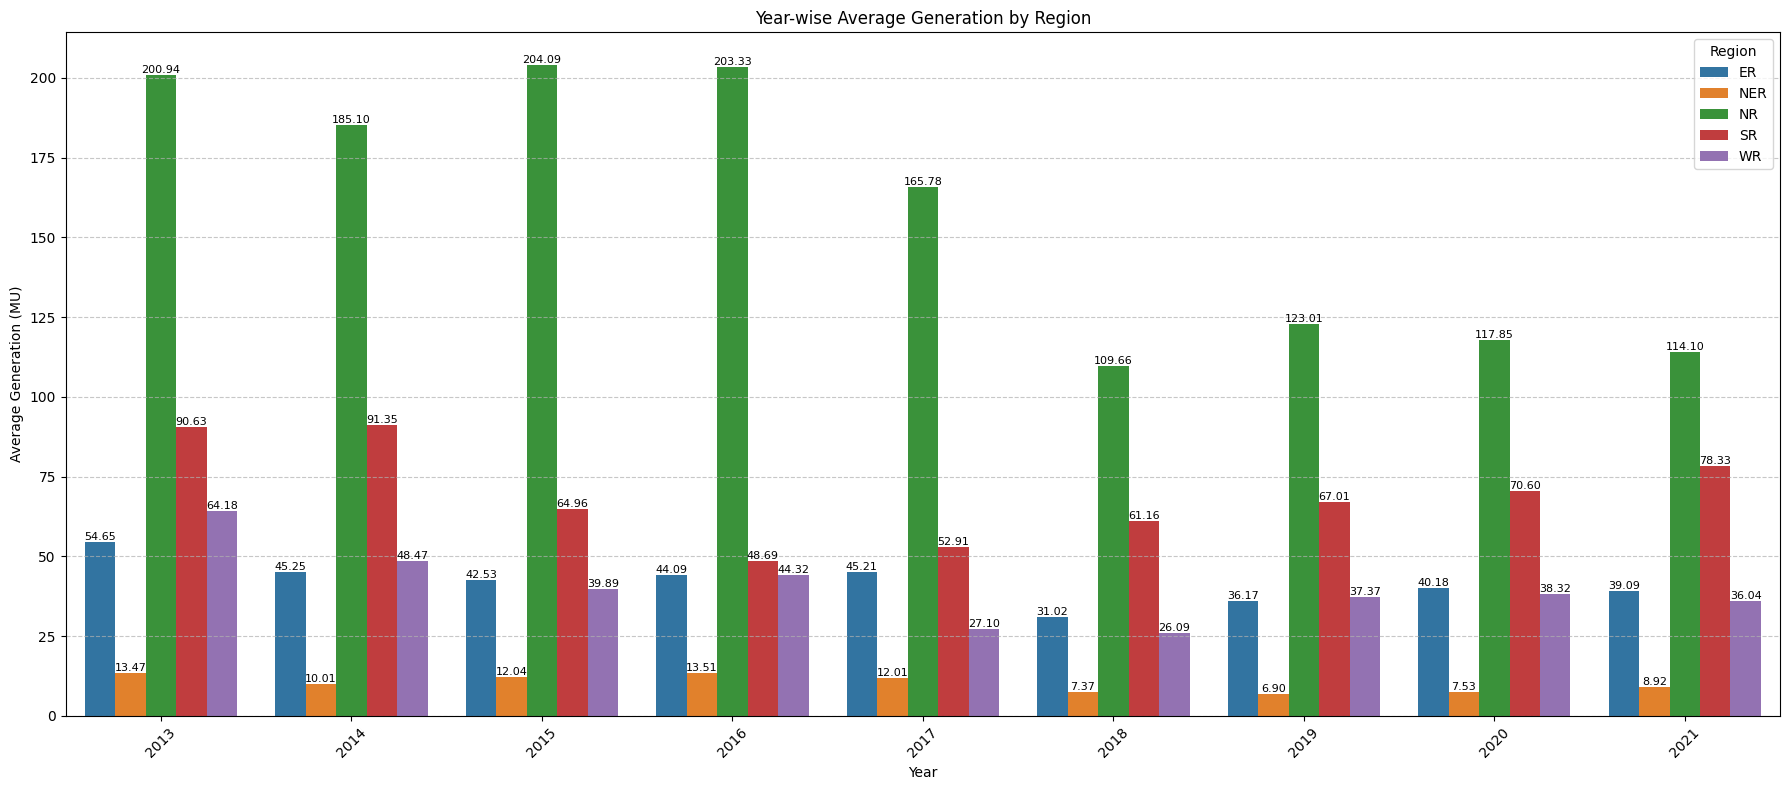

In [ ]:
avg_generation_yearly_region = df.groupby(['Year', 'Region'])['Generation'].mean().reset_index()

plt.figure(figsize=(18, 8))
sns.barplot(data=avg_generation_yearly_region, x='Year', y='Generation', hue='Region', palette='tab10')

# Add average values on top of the bars
for container in plt.gca().containers:
    for bar in container:
        height = bar.get_height()
        plt.gca().text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.title('Year-wise Average Generation by Region')
plt.xlabel('Year')
plt.ylabel('Average Generation (MU)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

Analysis :

1. Northern Region (NR) Dominates Across All Years
2. General Decline Around 2017–2018
3. North Eastern Region (NER) Records The Lowest Average Generation Every Year

4.2.5 Multiline plot : Total Generation by Month in year

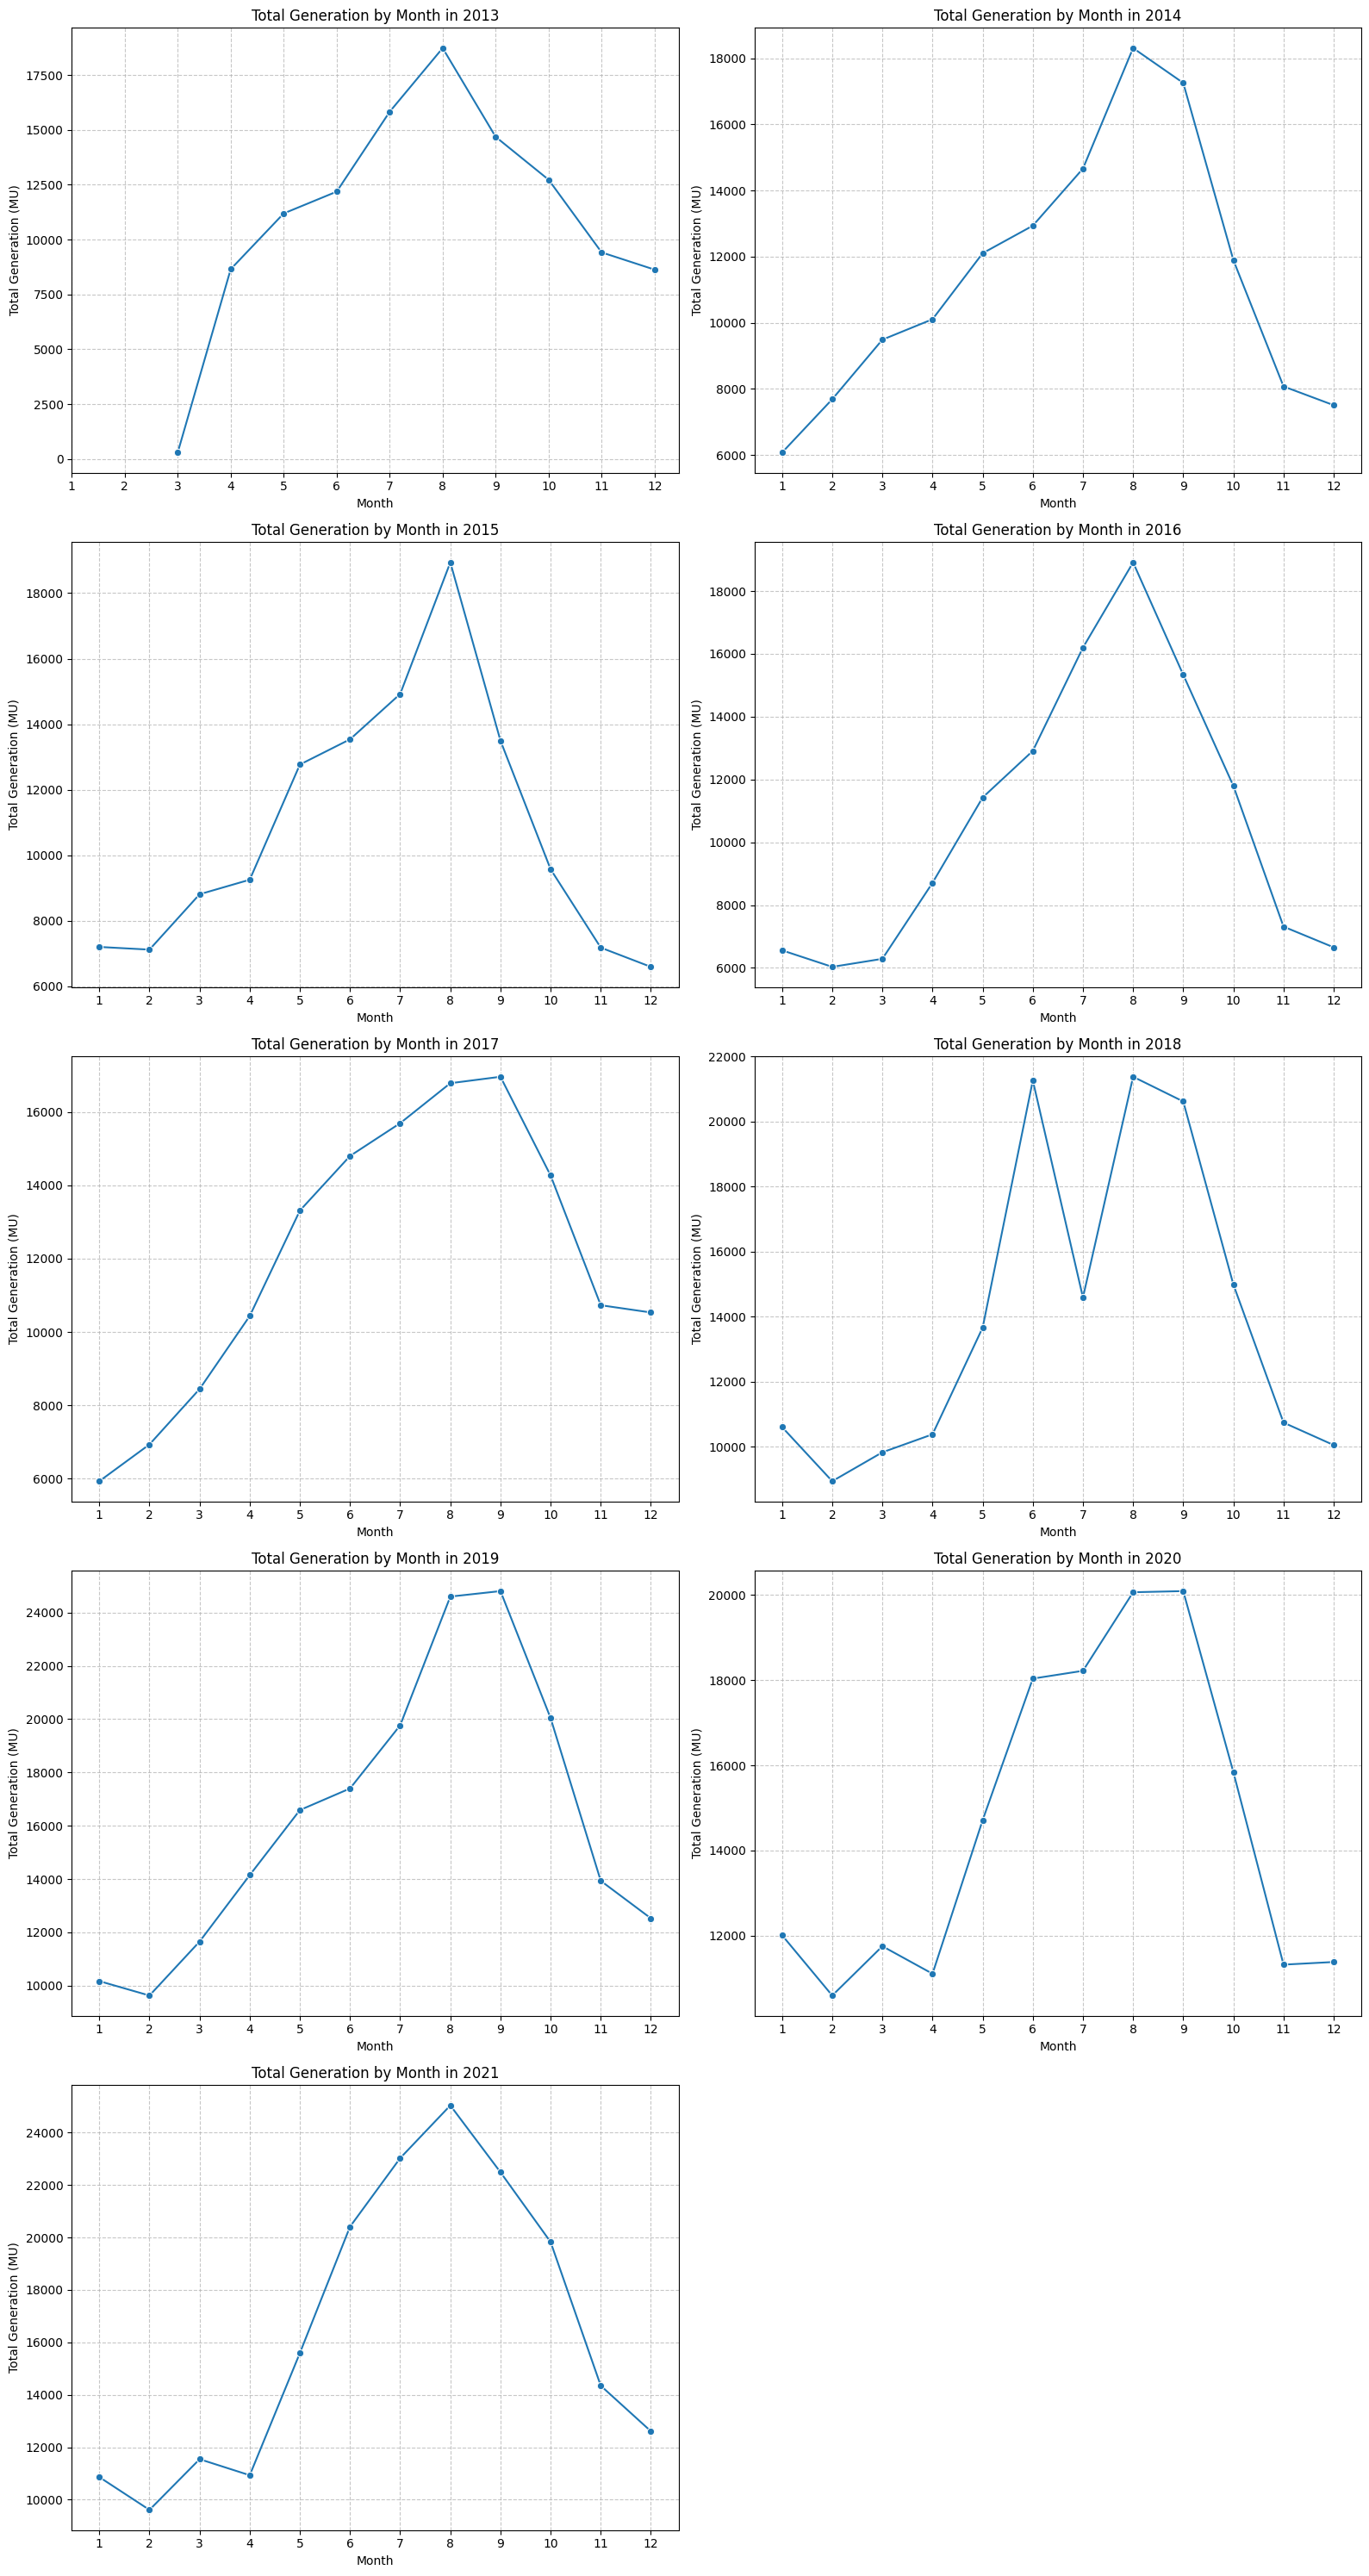

In [ ]:
total_generation_yearly_monthly = df.groupby(['Year', 'Month'])['Generation'].sum().reset_index()

unique_years = total_generation_yearly_monthly['Year'].unique()
num_years = len(unique_years)

n_cols = 2  # Number of columns for subplots
n_rows = (num_years + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 8, n_rows * 6))

for i, year in enumerate(unique_years):
    plt.subplot(n_rows, n_cols, i + 1)
    year_data = total_generation_yearly_monthly[total_generation_yearly_monthly['Year'] == year]
    sns.lineplot(data=year_data, x='Month', y='Generation', marker='o')
    plt.title(f'Total Generation by Month in {year}')
    plt.xlabel('Month')
    plt.ylabel('Total Generation (MU)')
    plt.xticks(range(1, 13))
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Analysis :

1. Consistent Seasonal Peaks
2. The 2018 Anomaly
3. Long-Term Volume Growth

### 4.3 Trivariate Analysis

4.3.1 HeatMap : Average Generation (MU) by Year and Month

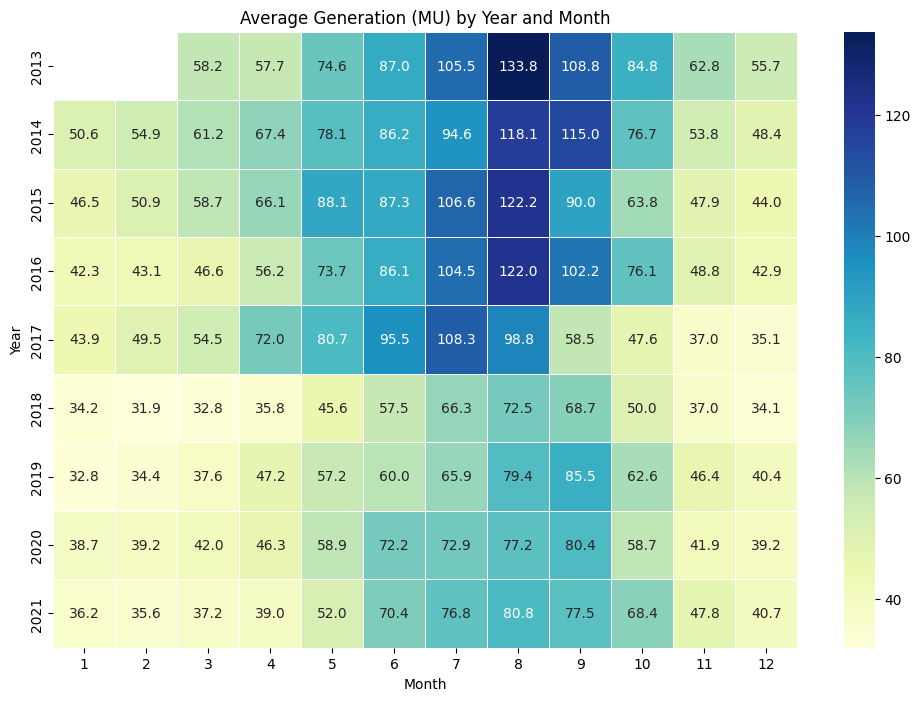

In [ ]:
avg_generation_month_year = df.groupby(['Year', 'Month'])['Generation'].mean().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(avg_generation_month_year, annot=True, cmap='YlGnBu', fmt='.1f', linewidths=.5)
plt.title('Average Generation (MU) by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

Analysis :

1. Consistent Summer Peaks
2. Overall Downward Trend
3. Predictable Winter Lows

4.3.2 HeatMap : Average Generation (MU) by Year and Source

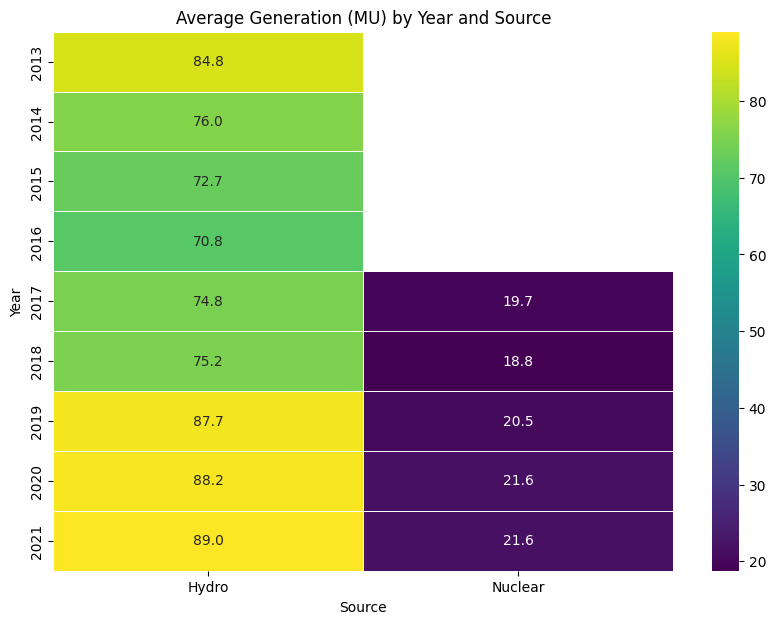

In [ ]:
avg_generation_source_year = df.groupby(['Year', 'source'])['Generation'].mean().unstack()

plt.figure(figsize=(10, 7))
sns.heatmap(avg_generation_source_year, annot=True, cmap='viridis', fmt='.1f', linewidths=.5)
plt.title('Average Generation (MU) by Year and Source')
plt.xlabel('Source')
plt.ylabel('Year')
plt.show()

Analysis :

1. Consistent Summer Peaks
2. Hydro Power Dominance
3. Late Nuclear Emergence

4.3.3 Heat Map : Average Generation (MU) by Year and Region

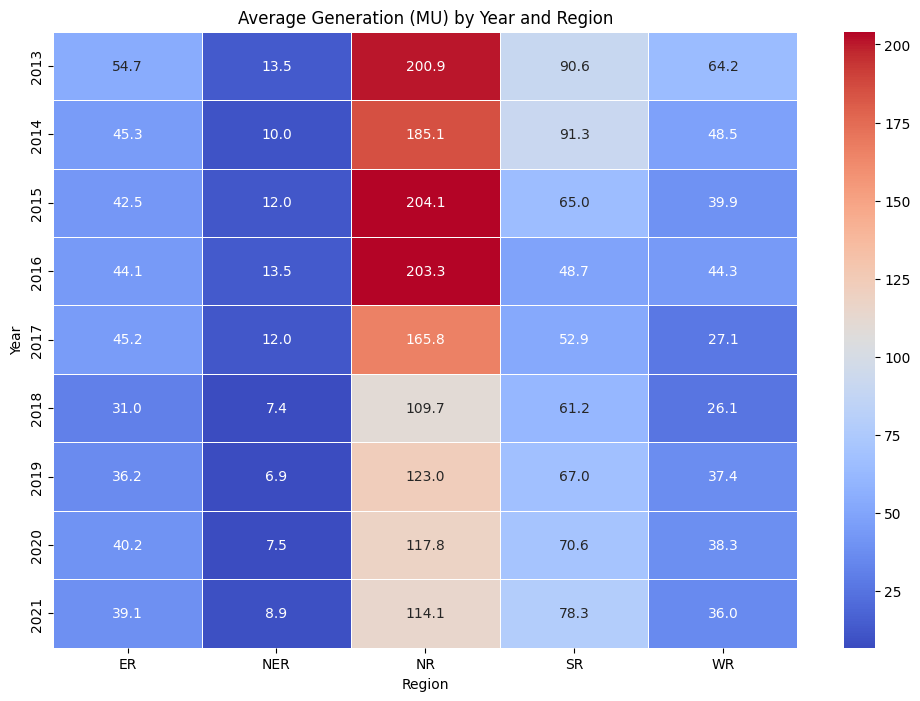

In [ ]:
avg_generation_region_year = df.groupby(['Year', 'Region'])['Generation'].mean().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(avg_generation_region_year, annot=True, cmap='coolwarm', fmt='.1f', linewidths=.5)
plt.title('Average Generation (MU) by Year and Region')
plt.xlabel('Region')
plt.ylabel('Year')
plt.show()

Analysis :

1. NR Region Dominance
2. NER Region Lows
3. Post-2016 NR Decline

4.3.4 Multi Line Plot : Average Generation by Month & Source in Each Year

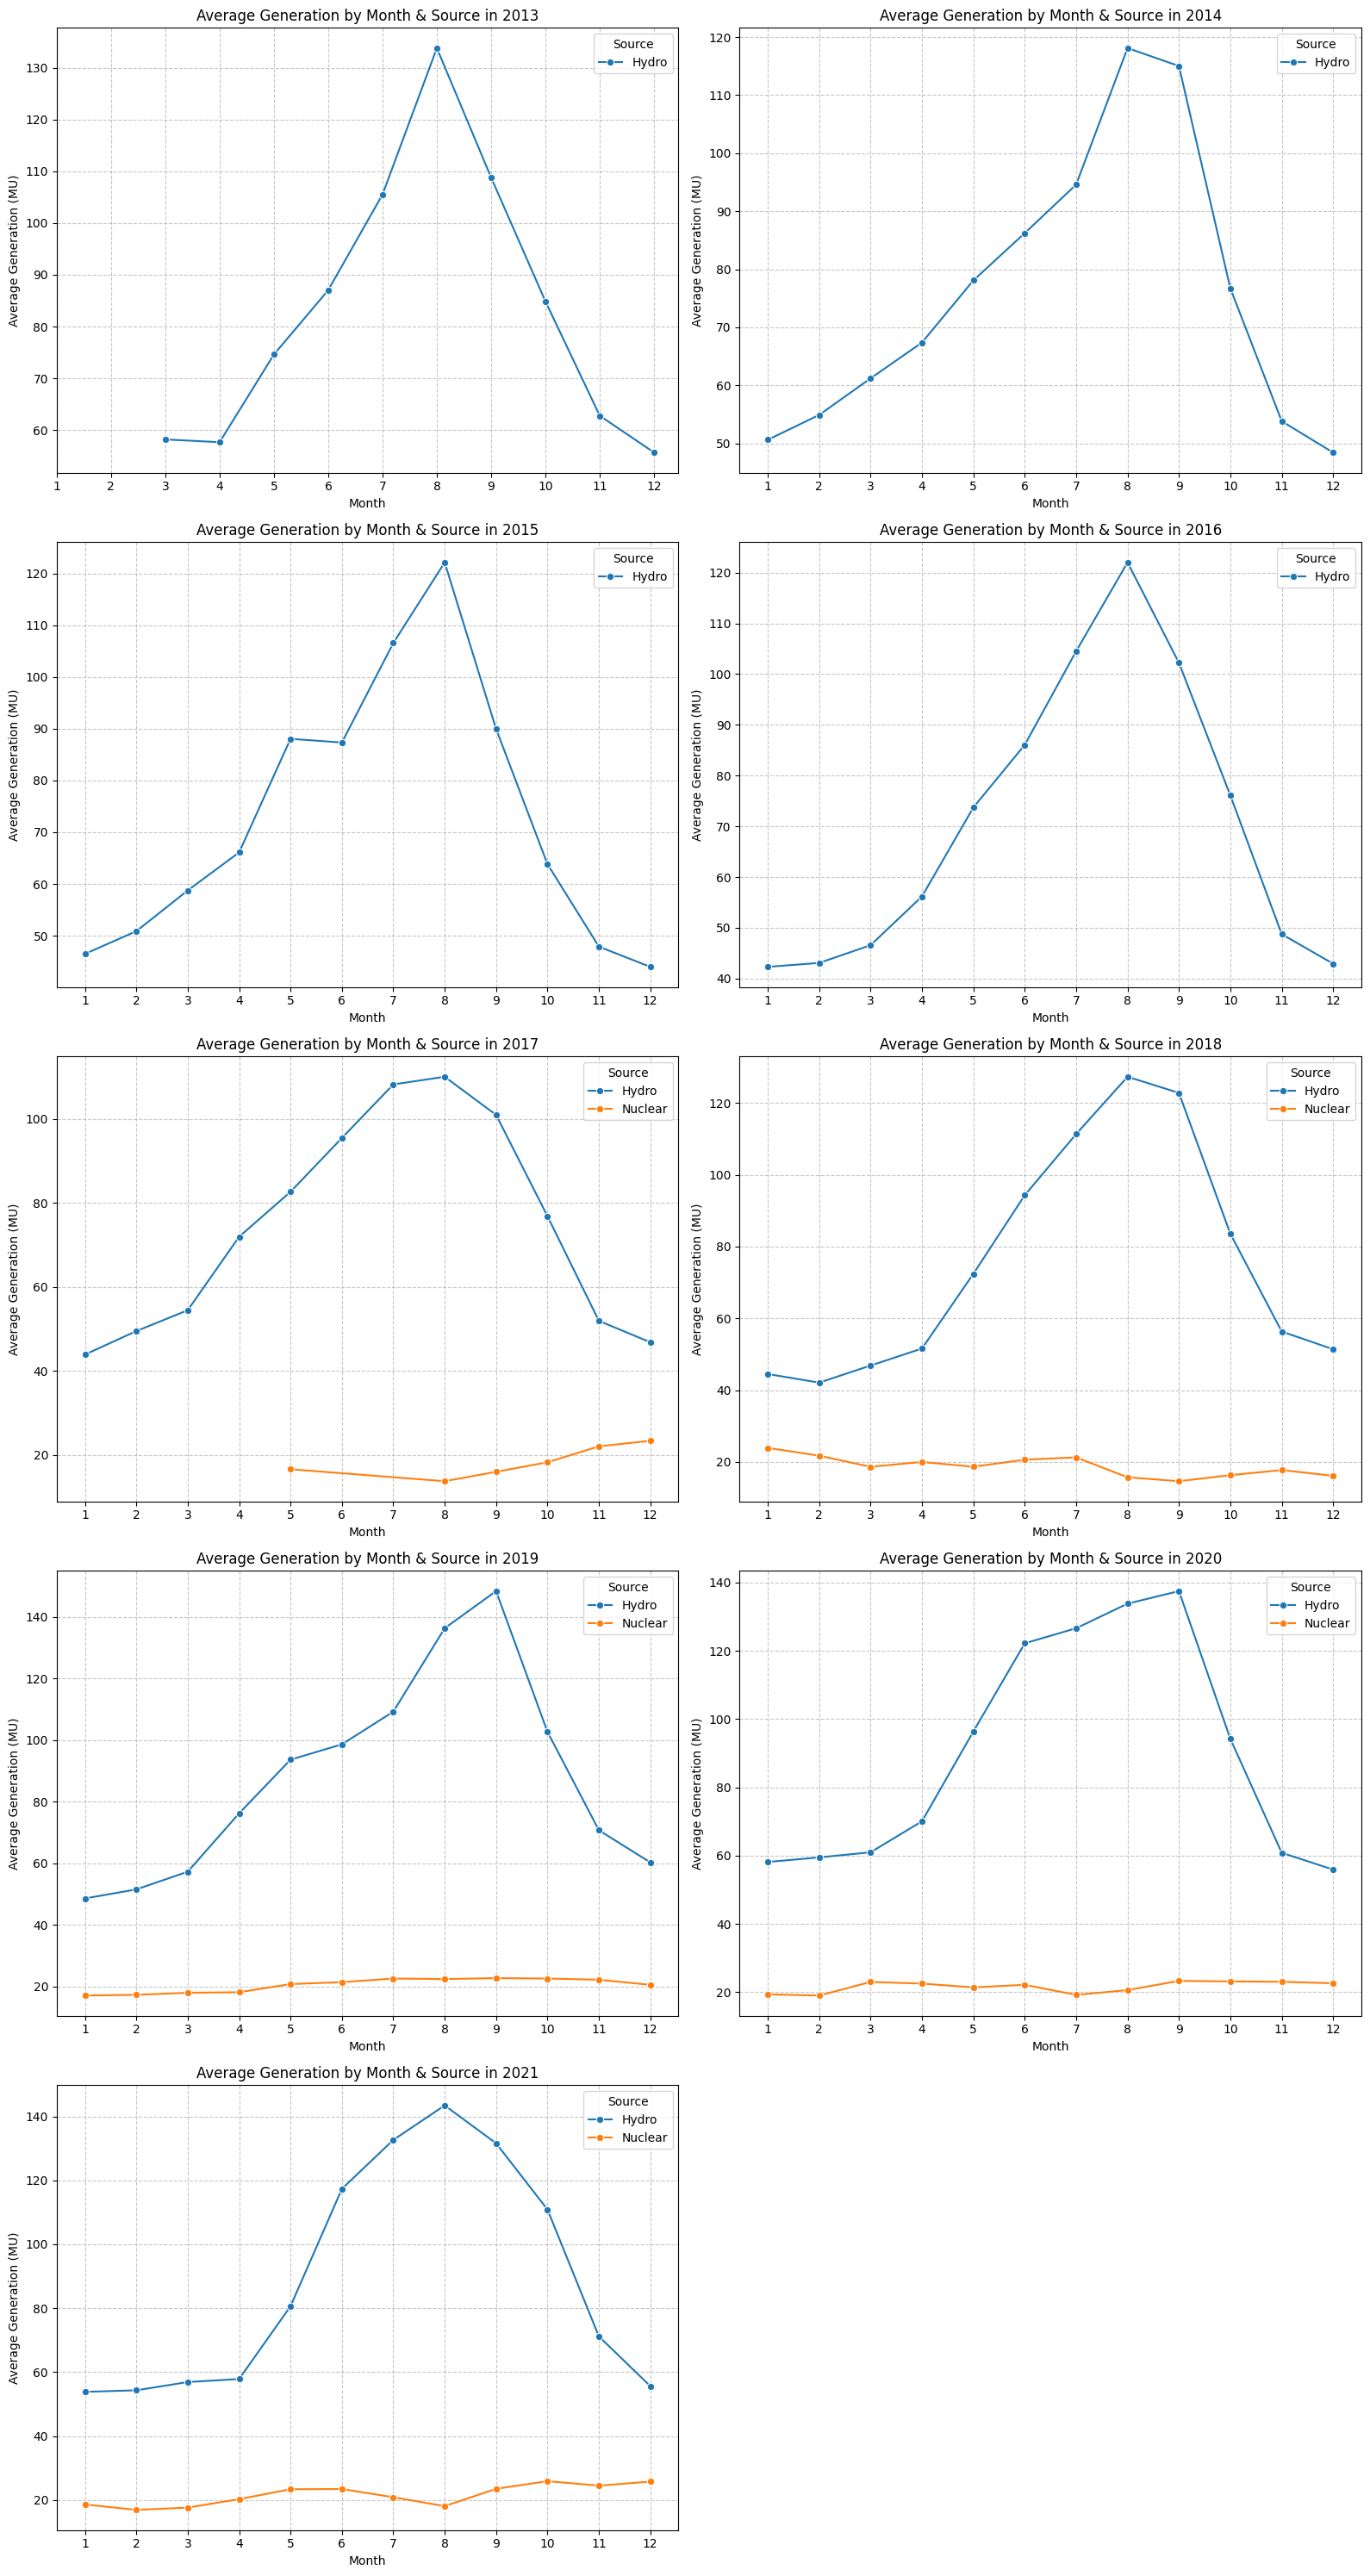

In [ ]:
avg_generation_yearly_monthly_source = df.groupby(['Year', 'Month', 'source'])['Generation'].mean().reset_index()

unique_years = avg_generation_yearly_monthly_source['Year'].unique()
num_years = len(unique_years)

n_cols = 2  # Number of columns for subplots
n_rows = (num_years + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 8, n_rows * 6))

for i, year in enumerate(unique_years):
    plt.subplot(n_rows, n_cols, i + 1)
    year_data = avg_generation_yearly_monthly_source[avg_generation_yearly_monthly_source['Year'] == year]
    sns.lineplot(data=year_data, x='Month', y='Generation', hue='source', marker='o')
    plt.title(f'Average Generation by Month & Source in {year}')
    plt.xlabel('Month')
    plt.ylabel('Average Generation (MU)')
    plt.xticks(range(1, 13))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Source')

plt.tight_layout()
plt.show()

Analysis :

1. Hydro Seasonal Peaks
2. Flat Nuclear Output
3. Late Nuclear Entry

4.3.5 Multi Line Plot : Average Generation by Month & Region in Each Year

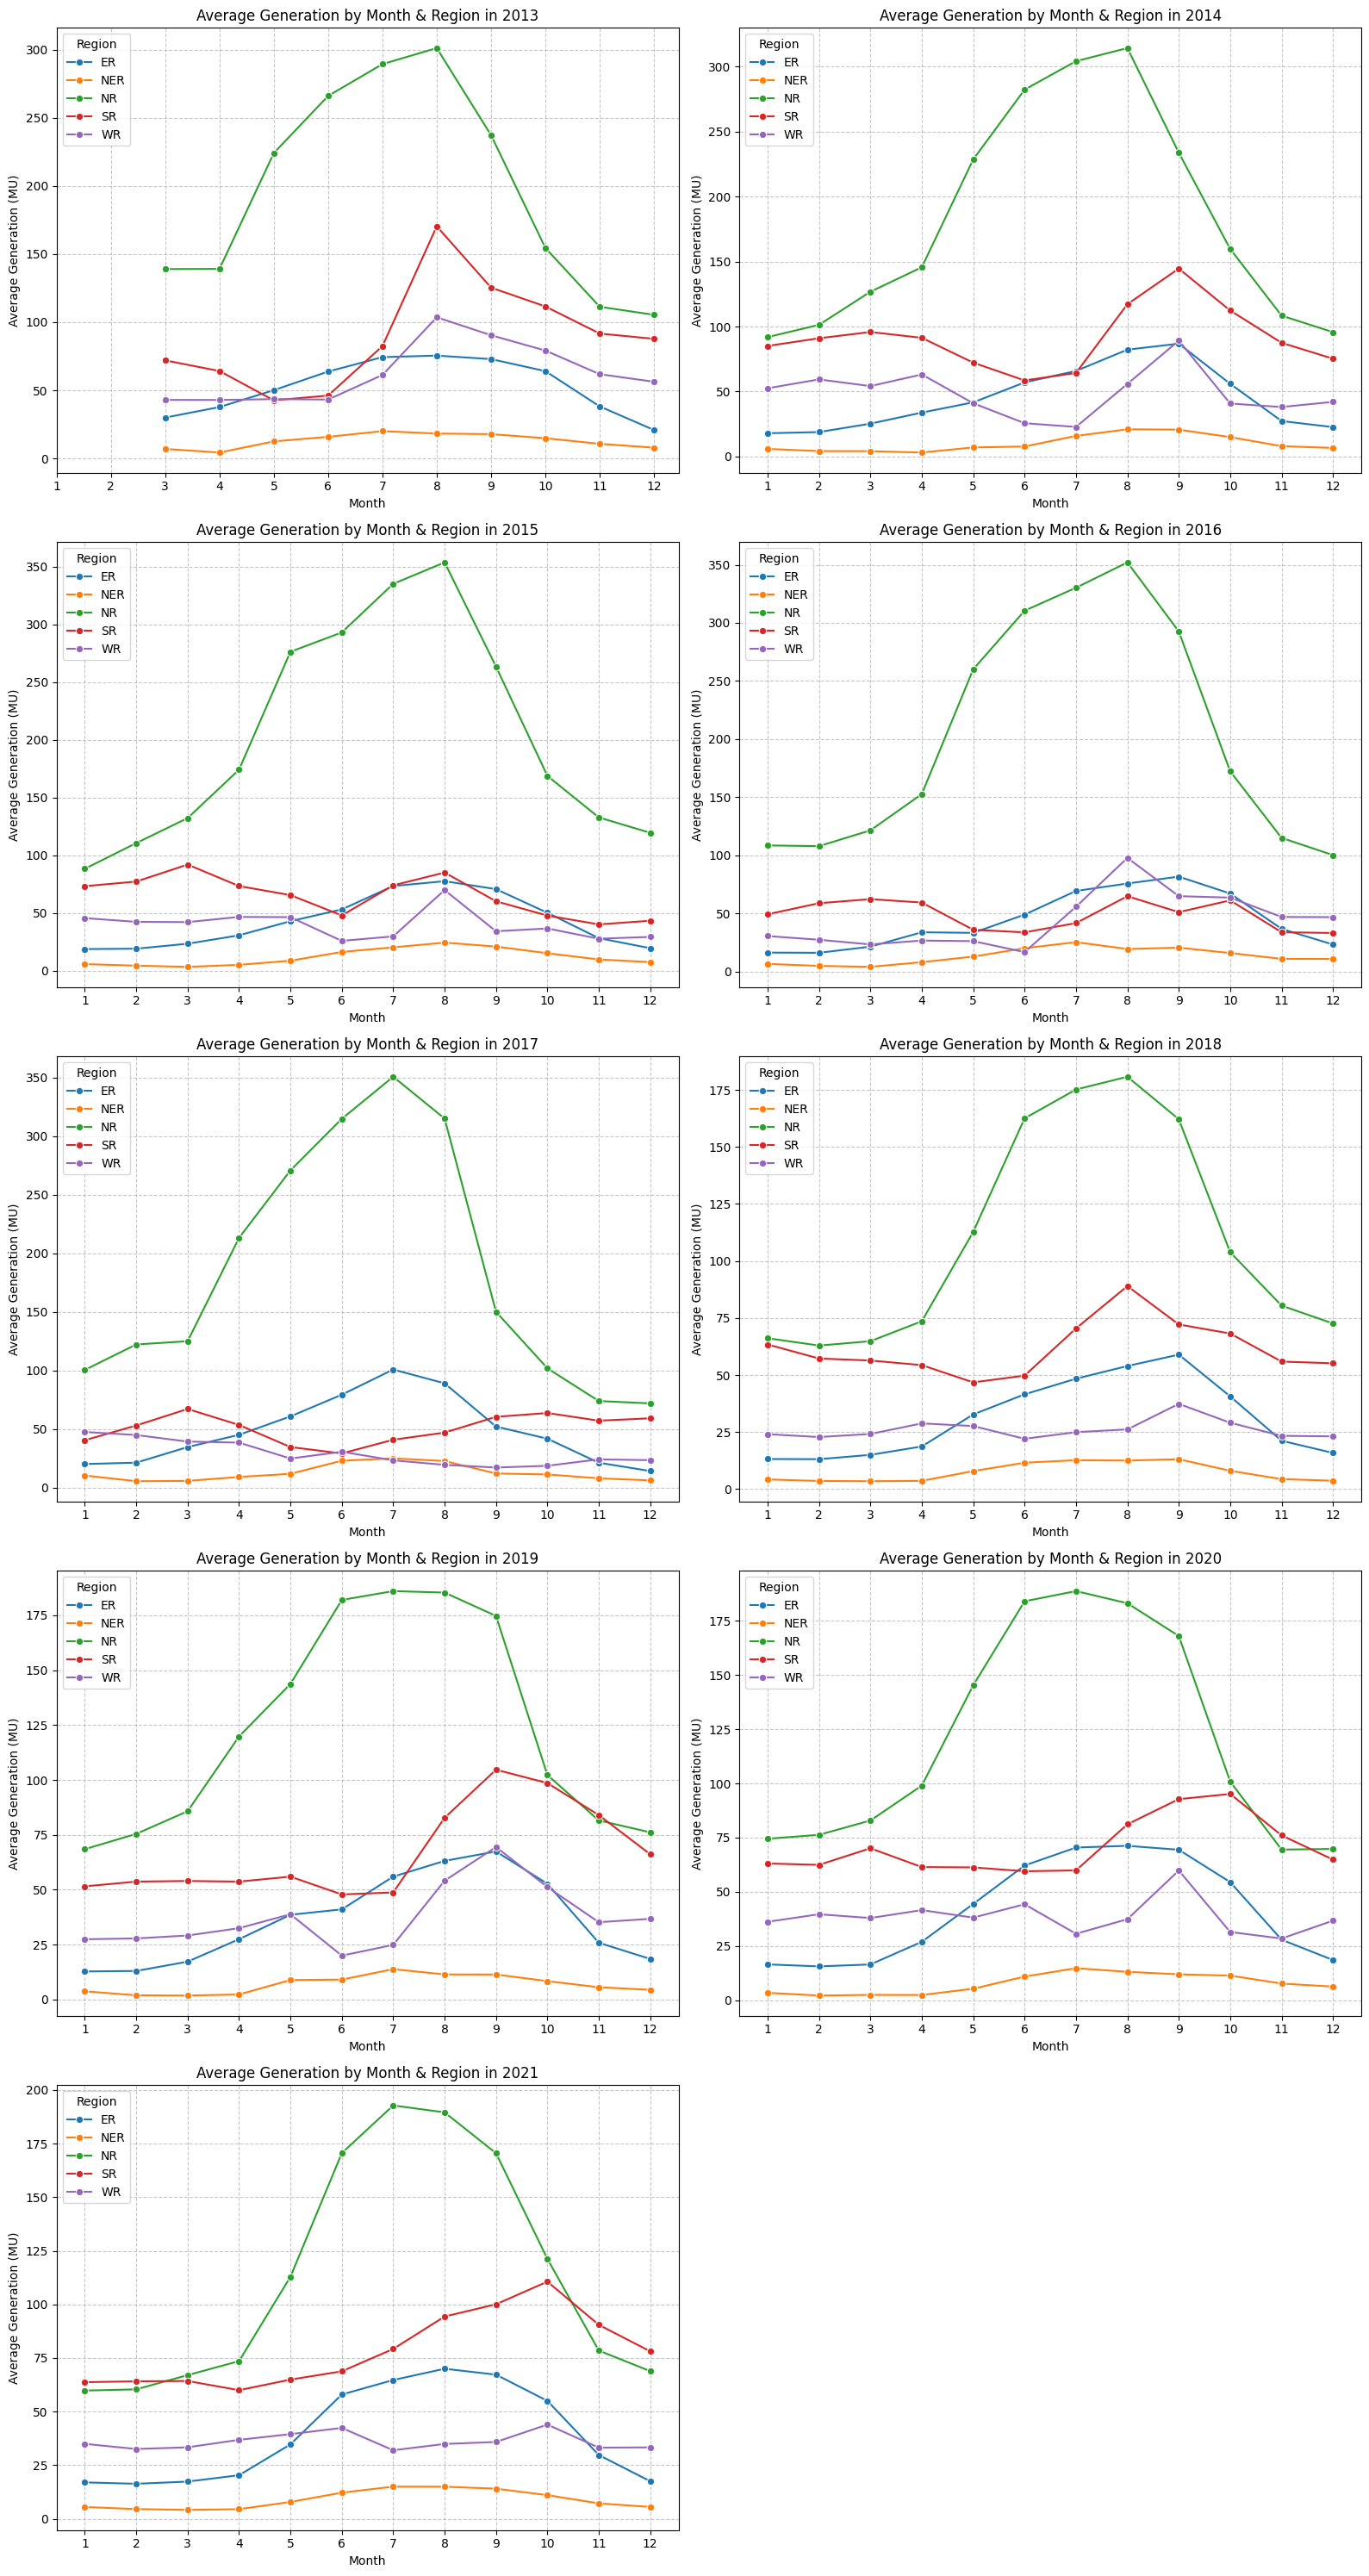

In [ ]:
avg_generation_yearly_monthly_region = df.groupby(['Year', 'Month', 'Region'])['Generation'].mean().reset_index()

unique_years = avg_generation_yearly_monthly_region['Year'].unique()
num_years = len(unique_years)

n_cols = 2  # Number of columns for subplots
n_rows = (num_years + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 8, n_rows * 6))

for i, year in enumerate(unique_years):
    plt.subplot(n_rows, n_cols, i + 1)
    year_data = avg_generation_yearly_monthly_region[avg_generation_yearly_monthly_region['Year'] == year]
    sns.lineplot(data=year_data, x='Month', y='Generation', hue='Region', marker='o', palette='tab10')
    plt.title(f'Average Generation by Month & Region in {year}')
    plt.xlabel('Month')
    plt.ylabel('Average Generation (MU)')
    plt.xticks(range(1, 13))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Region', loc='upper left')

plt.tight_layout()
plt.show()

Analysis

1. NR Summer Spikes
2. Flat NER Output
3. Post-2017 Volume Drop

## 5. Data Preprocessing And Feature Engineering

### 5.1 Handling Missing Value

In [ ]:
df.isna().sum()

,0
date,0
source,0
Region,0
Generation,0
Day,0
Month,0
Year,0
dayofweek,0
weekofyear,0
quarter,0


In [ ]:
# Day Value range between 1 to 31 . No any arbitary value
df['Day'].unique()

array([31,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30],
      dtype=int32)

In [ ]:
# month Value range between 1 to 12 . No any arbitary value
df['Month'].unique()

array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2], dtype=int32)

In [ ]:
# year value range between 2013 to 2021 . No any arbitary value
df['Year'].unique()

array([2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021], dtype=int32)

In [ ]:
# only two source . No any arbitary value
df['source'].unique()

array(['Hydro', 'Nuclear'], dtype=object)

In [ ]:
#Only 5 region. No any arbitary value
df['Region'].unique()

array(['ER', 'NER', 'NR', 'SR', 'WR'], dtype=object)

Conclusion :

There is No any NaN values as well as  custom missing value .

### 5.2 Handling Duplicate Values

In [ ]:
print(df[df.duplicated(keep=False)])

            date   source Region  Generation  Day  Month  Year  dayofweek  \
id                                                                          
4337  2015-09-09    Hydro     ER        76.0    9      9  2015          2   
4338  2015-09-09    Hydro     ER        76.0    9      9  2015          2   
11326 2018-08-18    Hydro     ER       109.0   18      8  2018          5   
11327 2018-08-18    Hydro     ER       109.0   18      8  2018          5   
15326 2019-10-01    Hydro     ER       132.0    1     10  2019          1   
...          ...      ...    ...         ...  ...    ...   ...        ...   
11135 2018-07-28  Nuclear     WR        30.0   28      7  2018          5   
11509 2018-09-04  Nuclear     WR        27.0    4      9  2018          1   
11510 2018-09-04  Nuclear     WR        27.0    4      9  2018          1   
12329 2018-11-27  Nuclear     WR        19.0   27     11  2018          1   
12330 2018-11-27  Nuclear     WR        19.0   27     11  2018          1   

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
print("Number of Duplicate Records : ",df.duplicated().sum())

Number of Duplicate Records :  0


Conclusion :

There are 90 duplicate records that were removed .

### 5.3 Handling Outlier

Conclusion  :

*   Since Date,Source and Region are catgory feature we cannot do outlier
*   Also Generation is our Traget Features . So There is No Need of Outlier




### 5.4 Creating Lag and Rolling Features

Autocorrelation Function And Partial Autocorrelation Function Plot

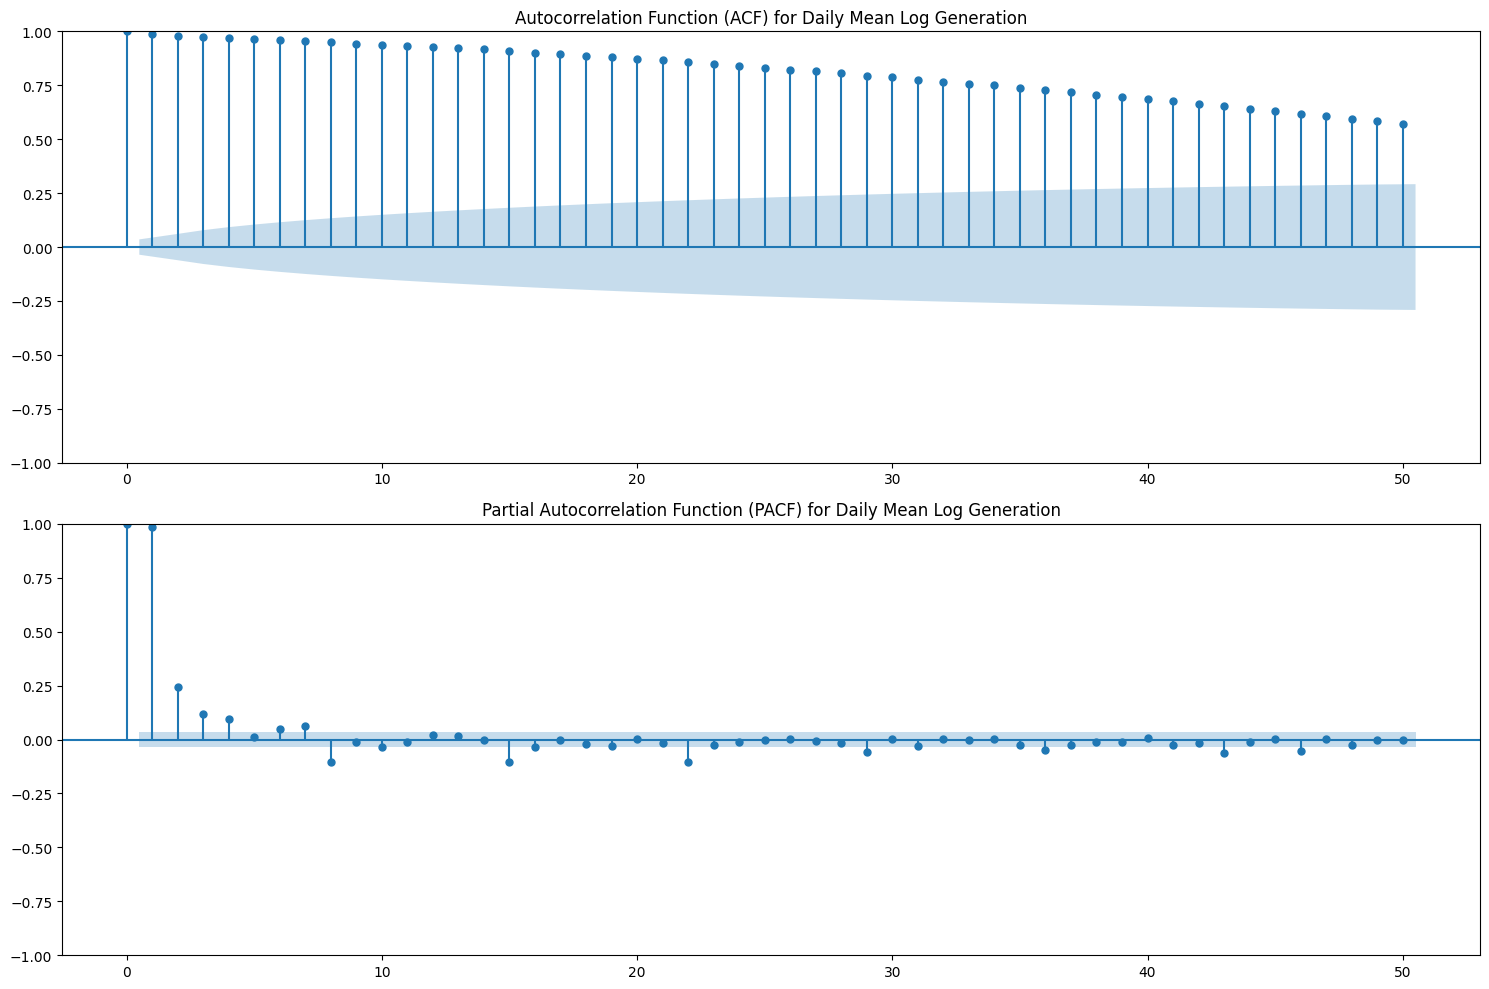

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

daily_mean_generation_log = df.groupby('date')['Generation'].mean().sort_index()

plt.figure(figsize=(15, 10))

plt.subplot(211)
plot_acf(daily_mean_generation_log, lags=50, ax=plt.gca(), title='Autocorrelation Function (ACF) for Daily Mean Log Generation')

plt.subplot(212)
plot_pacf(daily_mean_generation_log, lags=50, ax=plt.gca(), title='Partial Autocorrelation Function (PACF) for Daily Mean Log Generation')

plt.tight_layout()
plt.show()

In [ ]:
df['lag_1'] = df.groupby(['Region','source'])['Generation'].shift(1)
df['lag_7'] = df.groupby(['Region','source'])['Generation'].shift(7)
df['lag_14'] =df.groupby(['Region','source'])['Generation'].shift(14)
df['lag_30'] =df.groupby(['Region','source'])['Generation'].shift(30)
display(df.head())

,date,source,Region,Generation,Day,Month,Year,dayofweek,weekofyear,quarter,is_weekend,lag_1,lag_7,lag_14,lag_30
id,,,,,,,,,,,,,,,
1,2013-03-31,Hydro,ER,30.0,31,3,2013,6,13,1,1,NaN,NaN,NaN,NaN
6,2013-04-01,Hydro,ER,32.0,1,4,2013,0,14,2,0,30.0,NaN,NaN,NaN
11,2013-04-02,Hydro,ER,29.0,2,4,2013,1,14,2,0,32.0,NaN,NaN,NaN
16,2013-04-03,Hydro,ER,38.0,3,4,2013,2,14,2,0,29.0,NaN,NaN,NaN
21,2013-04-04,Hydro,ER,38.0,4,4,2013,3,14,2,0,38.0,NaN,NaN,NaN


In [ ]:
df['rolling_mean_7'] = df.groupby(['Region','source'])['Generation'].shift(1).rolling(window=7).mean()
df['rolling_mean_14'] = df.groupby(['Region','source'])['Generation'].shift(1).rolling(window=14).mean()
df['rolling_mean_30'] = df.groupby(['Region','source'])['Generation'].shift(1).rolling(window=30).mean()
display(df.head())

,date,source,Region,Generation,Day,Month,Year,dayofweek,weekofyear,quarter,is_weekend,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30
id,,,,,,,,,,,,,,,,,,
1,2013-03-31,Hydro,ER,30.0,31,3,2013,6,13,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2013-04-01,Hydro,ER,32.0,1,4,2013,0,14,2,0,30.0,NaN,NaN,NaN,NaN,NaN,NaN
11,2013-04-02,Hydro,ER,29.0,2,4,2013,1,14,2,0,32.0,NaN,NaN,NaN,NaN,NaN,NaN
16,2013-04-03,Hydro,ER,38.0,3,4,2013,2,14,2,0,29.0,NaN,NaN,NaN,NaN,NaN,NaN
21,2013-04-04,Hydro,ER,38.0,4,4,2013,3,14,2,0,38.0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df=df.dropna().reset_index(drop=True)
df.head()

,date,source,Region,Generation,Day,Month,Year,dayofweek,weekofyear,quarter,is_weekend,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30
0,2013-04-30,Hydro,ER,51.0,30,4,2013,1,18,2,0,46.0,37.0,31.0,30.0,38.857143,35.714286,37.033333
1,2013-05-01,Hydro,ER,48.0,1,5,2013,2,18,2,0,51.0,38.0,38.0,32.0,40.857143,37.142857,37.733333
2,2013-05-02,Hydro,ER,55.0,2,5,2013,3,18,2,0,48.0,36.0,40.0,29.0,42.285714,37.857143,38.266667
3,2013-05-03,Hydro,ER,52.0,3,5,2013,4,18,2,0,55.0,29.0,33.0,38.0,45.000000,38.928571,39.133333
4,2013-05-04,Hydro,ER,47.0,4,5,2013,5,18,2,1,52.0,46.0,27.0,38.0,48.285714,40.285714,39.600000


Conclusion :

We Have Created lag feature and Rolling Mean

### 5.5 Remove Unnecessary Features

In [ ]:
##df.drop('date', axis=1, inplace=True)
df.drop('Day', axis=1, inplace=True)


Conclusion :

we have separate columns for day , month and year instead of single columns Date . So that model can be trained well

### 5.6 Handling Categorical Feature

In [ ]:
df = pd.get_dummies(df, columns=['Region','source'], drop_first=True)
display(df.head())

,date,Generation,Month,Year,dayofweek,weekofyear,quarter,is_weekend,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,Region_NER,Region_NR,Region_SR,Region_WR,source_Nuclear
0,2013-04-30,51.0,4,2013,1,18,2,0,46.0,37.0,31.0,30.0,38.857143,35.714286,37.033333,False,False,False,False,False
1,2013-05-01,48.0,5,2013,2,18,2,0,51.0,38.0,38.0,32.0,40.857143,37.142857,37.733333,False,False,False,False,False
2,2013-05-02,55.0,5,2013,3,18,2,0,48.0,36.0,40.0,29.0,42.285714,37.857143,38.266667,False,False,False,False,False
3,2013-05-03,52.0,5,2013,4,18,2,0,55.0,29.0,33.0,38.0,45.000000,38.928571,39.133333,False,False,False,False,False
4,2013-05-04,47.0,5,2013,5,18,2,1,52.0,46.0,27.0,38.0,48.285714,40.285714,39.600000,False,False,False,False,False


Conclusion :

Source and Region are Converted into Numeric Features using one hot encoding . We use one hot encoding beacuse only less no of unique values and there is no any priority in the values.

### 5.7 Feature Transformation

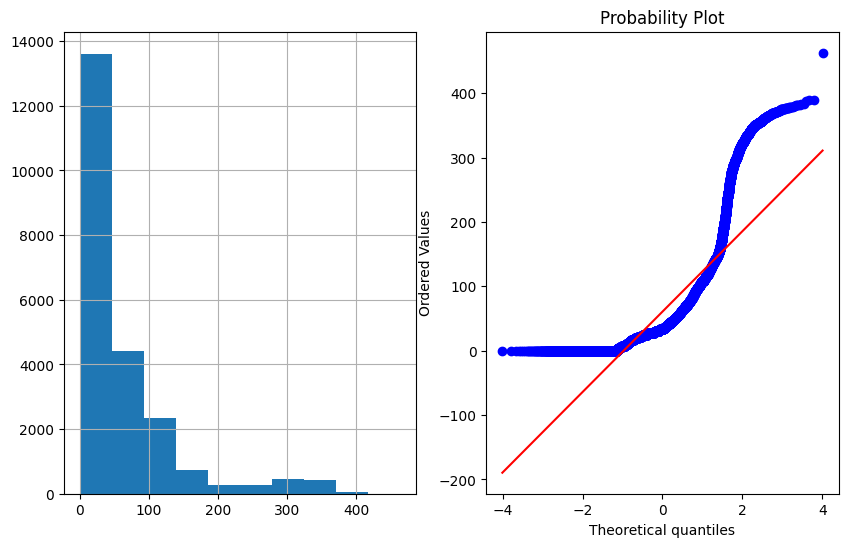

In [ ]:
import scipy.stats as stat
import pylab
def plot_data(df,feature):
    plt.figure(figsize=(10,6))
    plt.subplot(1,2,1)
    df[feature].hist()
    plt.subplot(1,2,2)
    stat.probplot(df[feature],dist='norm',plot=pylab)
    plt.show()
plot_data(df,'Generation')

Generation is Positively Right Skewed

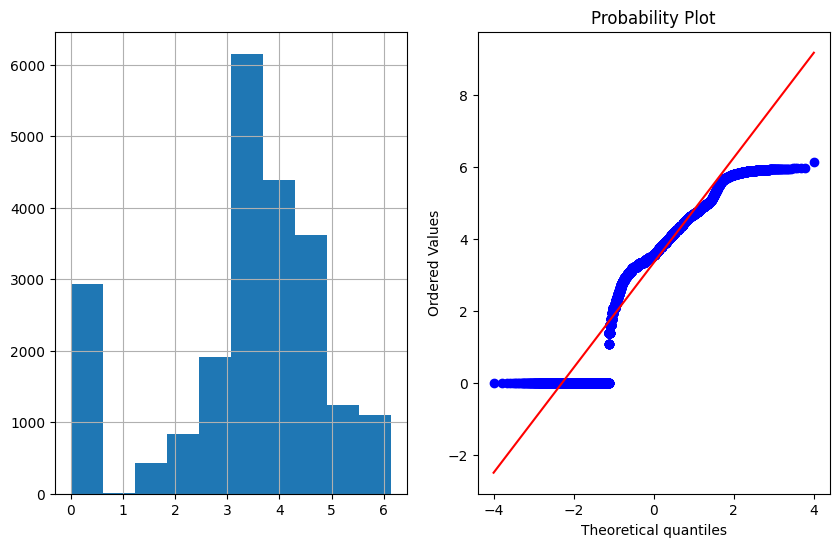

In [ ]:
df['Generation_log'] = np.log1p(df['Generation'])
plot_data(df,'Generation_log')

In [ ]:
##df.drop('Generation', axis=1, inplace=True)
df.columns

Index(['date', 'Generation', 'Month', 'Year', 'dayofweek', 'weekofyear',
       'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30',
       'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'Region_NER',
       'Region_NR', 'Region_SR', 'Region_WR', 'source_Nuclear',
       'Generation_log'],
      dtype='object')

Conclusion :

Generation was Right skewed, after the log transformation it becomes normally distributed curve

## 6. Model Buliding

### 6.1 Define Feature and Target

In [ ]:
x = df.drop(['Generation_log','Generation','date'],axis=1)
y = df['Generation_log']
print(x.columns)

Index(['Month', 'Year', 'dayofweek', 'weekofyear', 'quarter', 'is_weekend',
       'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7',
       'rolling_mean_14', 'rolling_mean_30', 'Region_NER', 'Region_NR',
       'Region_SR', 'Region_WR', 'source_Nuclear'],
      dtype='object')


### 6.3 Baseline Model Training

In [ ]:
from sklearn.model_selection import TimeSeriesSplit,RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

model = XGBRegressor(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

tscv = TimeSeriesSplit(n_splits=5)

rmse_scores = []

for train_idx, val_idx in tscv.split(x):
    X_train, X_val = x.iloc[train_idx], x.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, preds))
    rmse_scores.append(rmse)
print(rmse_scores)
print("Baseline RMSE:", np.mean(rmse_scores))

[np.float64(0.6267048517458564), np.float64(0.4369583644018194), np.float64(0.11701941377946432), np.float64(0.14516537225514858), np.float64(0.20756440027529593)]
Baseline RMSE: 0.3066824804915169


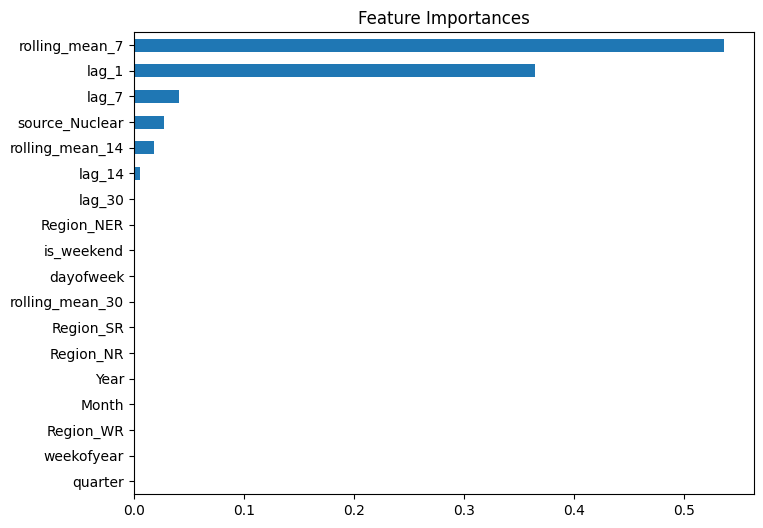

rolling_mean_7     0.536412
lag_1              0.364684
lag_7              0.040848
source_Nuclear     0.027215
rolling_mean_14    0.018079
lag_14             0.005045
lag_30             0.001308
Region_NER         0.001118
is_weekend         0.000903
dayofweek          0.000829
rolling_mean_30    0.000645
Region_SR          0.000509
Region_NR          0.000484
Year               0.000419
Month              0.000395
Region_WR          0.000381
weekofyear         0.000371
quarter            0.000354
dtype: float32


In [ ]:
model.fit(x, y)

importances = pd.Series(model.feature_importances_, index=x.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.title("Feature Importances")
plt.gca().invert_yaxis()
plt.show()

print(importances)

### 6.4 Baseline Model With Important Feature

In [ ]:

top_features = ['lag_1','rolling_mean_7','rolling_mean_14','lag_7', 'lag_14', 'source_Nuclear']

X_refined = x[top_features]

best_model = XGBRegressor(
n_estimators=1000,
max_depth=4,
learning_rate=0.03,
subsample=0.8,
colsample_bytree=0.8,
reg_lambda=10,
random_state=42,
objective='reg:squarederror',
n_jobs=-1
)

rmse_refined = []

for train_idx, val_idx in tscv.split(X_refined):
    X_tr, X_va = X_refined.iloc[train_idx], X_refined.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

    best_model.fit(X_tr, y_tr)
    p = best_model.predict(X_va)

    rmse_refined.append(np.sqrt(mean_squared_error(y_va, p)))

print("Average Refined RMSE:", np.mean(rmse_refined))


Average Refined RMSE: 0.3043895443743544


### 6.5 Hyper Tuning / Optimization

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid for RandomizedSearchCV
param_grid = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1, 5],
    'reg_lambda': [0, 0.1, 0.5, 1, 5]
}

# Initialize XGBRegressor with some fixed parameters
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Setup TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50, # Number of parameter settings that are sampled (adjust as needed)
    scoring='neg_root_mean_squared_error', # Objective is to minimize RMSE
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Fit RandomizedSearchCV
# X_refined was created using the top_features
random_search.fit(X_refined, y)

# Get the best estimator and its parameters
best_estimator = random_search.best_estimator_
best_params = random_search.best_params_
best_score = -random_search.best_score_ # Convert negative RMSE back to positive

print("Best Parameters found:", best_params)
print("Best Cross-Validation RMSE:", best_score)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters found: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best Cross-Validation RMSE: 0.2936800906898104


### 6.7 Final Model

In [ ]:
'''best_model.fit(X_refined, y)
final_model = best_model'''
final_model = best_estimator


# 7. Prediction

## 7.1 Load Test Data

In [ ]:
test_df = pd.read_csv("/content/drive/MyDrive/CEG ML Competitiom/CEG ML Competition/Smart Grid  Power Load in India/test.csv")
# Preserve IDs for final submission
test_ids = test_df['id'].values

In [ ]:
test_df.head()

## 7.2 Test Data Preprocessing

In [ ]:
test_df['date'] = pd.to_datetime(test_df['date'])
test_df = test_df.sort_values(['Region','source','date']).reset_index(drop=True)


# One-hot encoding
test_df = pd.get_dummies(test_df, columns=['Region','source'], drop_first=True)

# Add missing columns
for col in top_features:
    if col not in test_df.columns:
        test_df[col] = 0

# Ensure same order
test_df = test_df[top_features]

In [ ]:
test_df

,lag_1,rolling_mean_7,rolling_mean_14,lag_7,lag_14,source_Nuclear
0,0,0,0,0,0,False
1,0,0,0,0,0,False
2,0,0,0,0,0,False
3,0,0,0,0,0,False
4,0,0,0,0,0,False
...,...,...,...,...,...,...
4515,0,0,0,0,0,True
4516,0,0,0,0,0,True
4517,0,0,0,0,0,True
4518,0,0,0,0,0,True


In [ ]:
X_refined

,lag_1,rolling_mean_7,rolling_mean_14,lag_7,lag_14,source_Nuclear
0,46.0,38.857143,35.714286,37.0,31.0,False
1,51.0,40.857143,37.142857,38.0,38.0,False
2,48.0,42.285714,37.857143,36.0,40.0,False
3,55.0,45.000000,38.928571,29.0,33.0,False
4,52.0,48.285714,40.285714,46.0,27.0,False
...,...,...,...,...,...,...
22600,33.0,33.000000,33.000000,33.0,33.0,True
22601,33.0,33.000000,33.000000,33.0,33.0,True
22602,33.0,33.000000,33.000000,33.0,33.0,True
22603,33.0,33.000000,33.000000,33.0,33.0,True


## 7.3 Prediction

In [ ]:
history = df.copy()
predictions_log = []

source_cols = [col for col in history.columns if 'source_' in col]
region_cols = [col for col in history.columns if 'Region_' in col]

for _, row in test_df.iterrows():

    mask = True
    for col in source_cols:
        mask &= (history[col] == row[col])
    for col in region_cols:
        mask &= (history[col] == row[col])

    past_data = history[mask].sort_values('date')

    if len(past_data) < 30:
        predictions_log.append(0)
        continue

    # USE RAW GENERATION (IMPORTANT FIX)
    lag_1 = past_data['Generation'].iloc[-1]
    lag_7 = past_data['Generation'].iloc[-7]
    lag_14 = past_data['Generation'].iloc[-14]
    lag_30 = past_data['Generation'].iloc[-30]

    input_dict = row.to_dict()
    input_dict['lag_1'] = lag_1
    input_dict['lag_7'] = lag_7
    input_dict['lag_14'] = lag_14
    input_dict['lag_30'] = lag_30

    X_input = pd.DataFrame([input_dict])[top_features]

    pred_log = final_model.predict(X_input)[0]
    predictions_log.append(pred_log)

    # Convert back to raw
    pred_raw = np.expm1(pred_log)

    new_row = input_dict.copy()
    new_row['Generation'] = pred_raw
    new_row['Generation_log'] = pred_log
    new_row['date'] = pd.NaT

    history = pd.concat([history, pd.DataFrame([new_row])], ignore_index=True)


predictions = np.expm1(np.array(predictions_log))
predictions = np.clip(predictions, 0, None)

## 7.4 Submission File

In [ ]:
submission = pd.DataFrame({
    'id': test_ids,
    'Generation': predictions
})

submission.to_excel('submission.xlsx', index=False)

print("Submission file created successfully.")

In [ ]:
print(len(predictions))
print(len(test_ids))

# ------------------------------------- OVER ---------------------------------------